### Plot coefficient and eigenfunction
In this notebook we plot samples of different eigenfunctions $a(x,y)$ of the PDE and the corresponding local basis functions $\phi$. The investigations done in ex_FNO.py compute the data on an inner subdomain (subdom_idx=5) for 16 square subdomains of the global domain $[0,1]^2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import setup
import os as ops

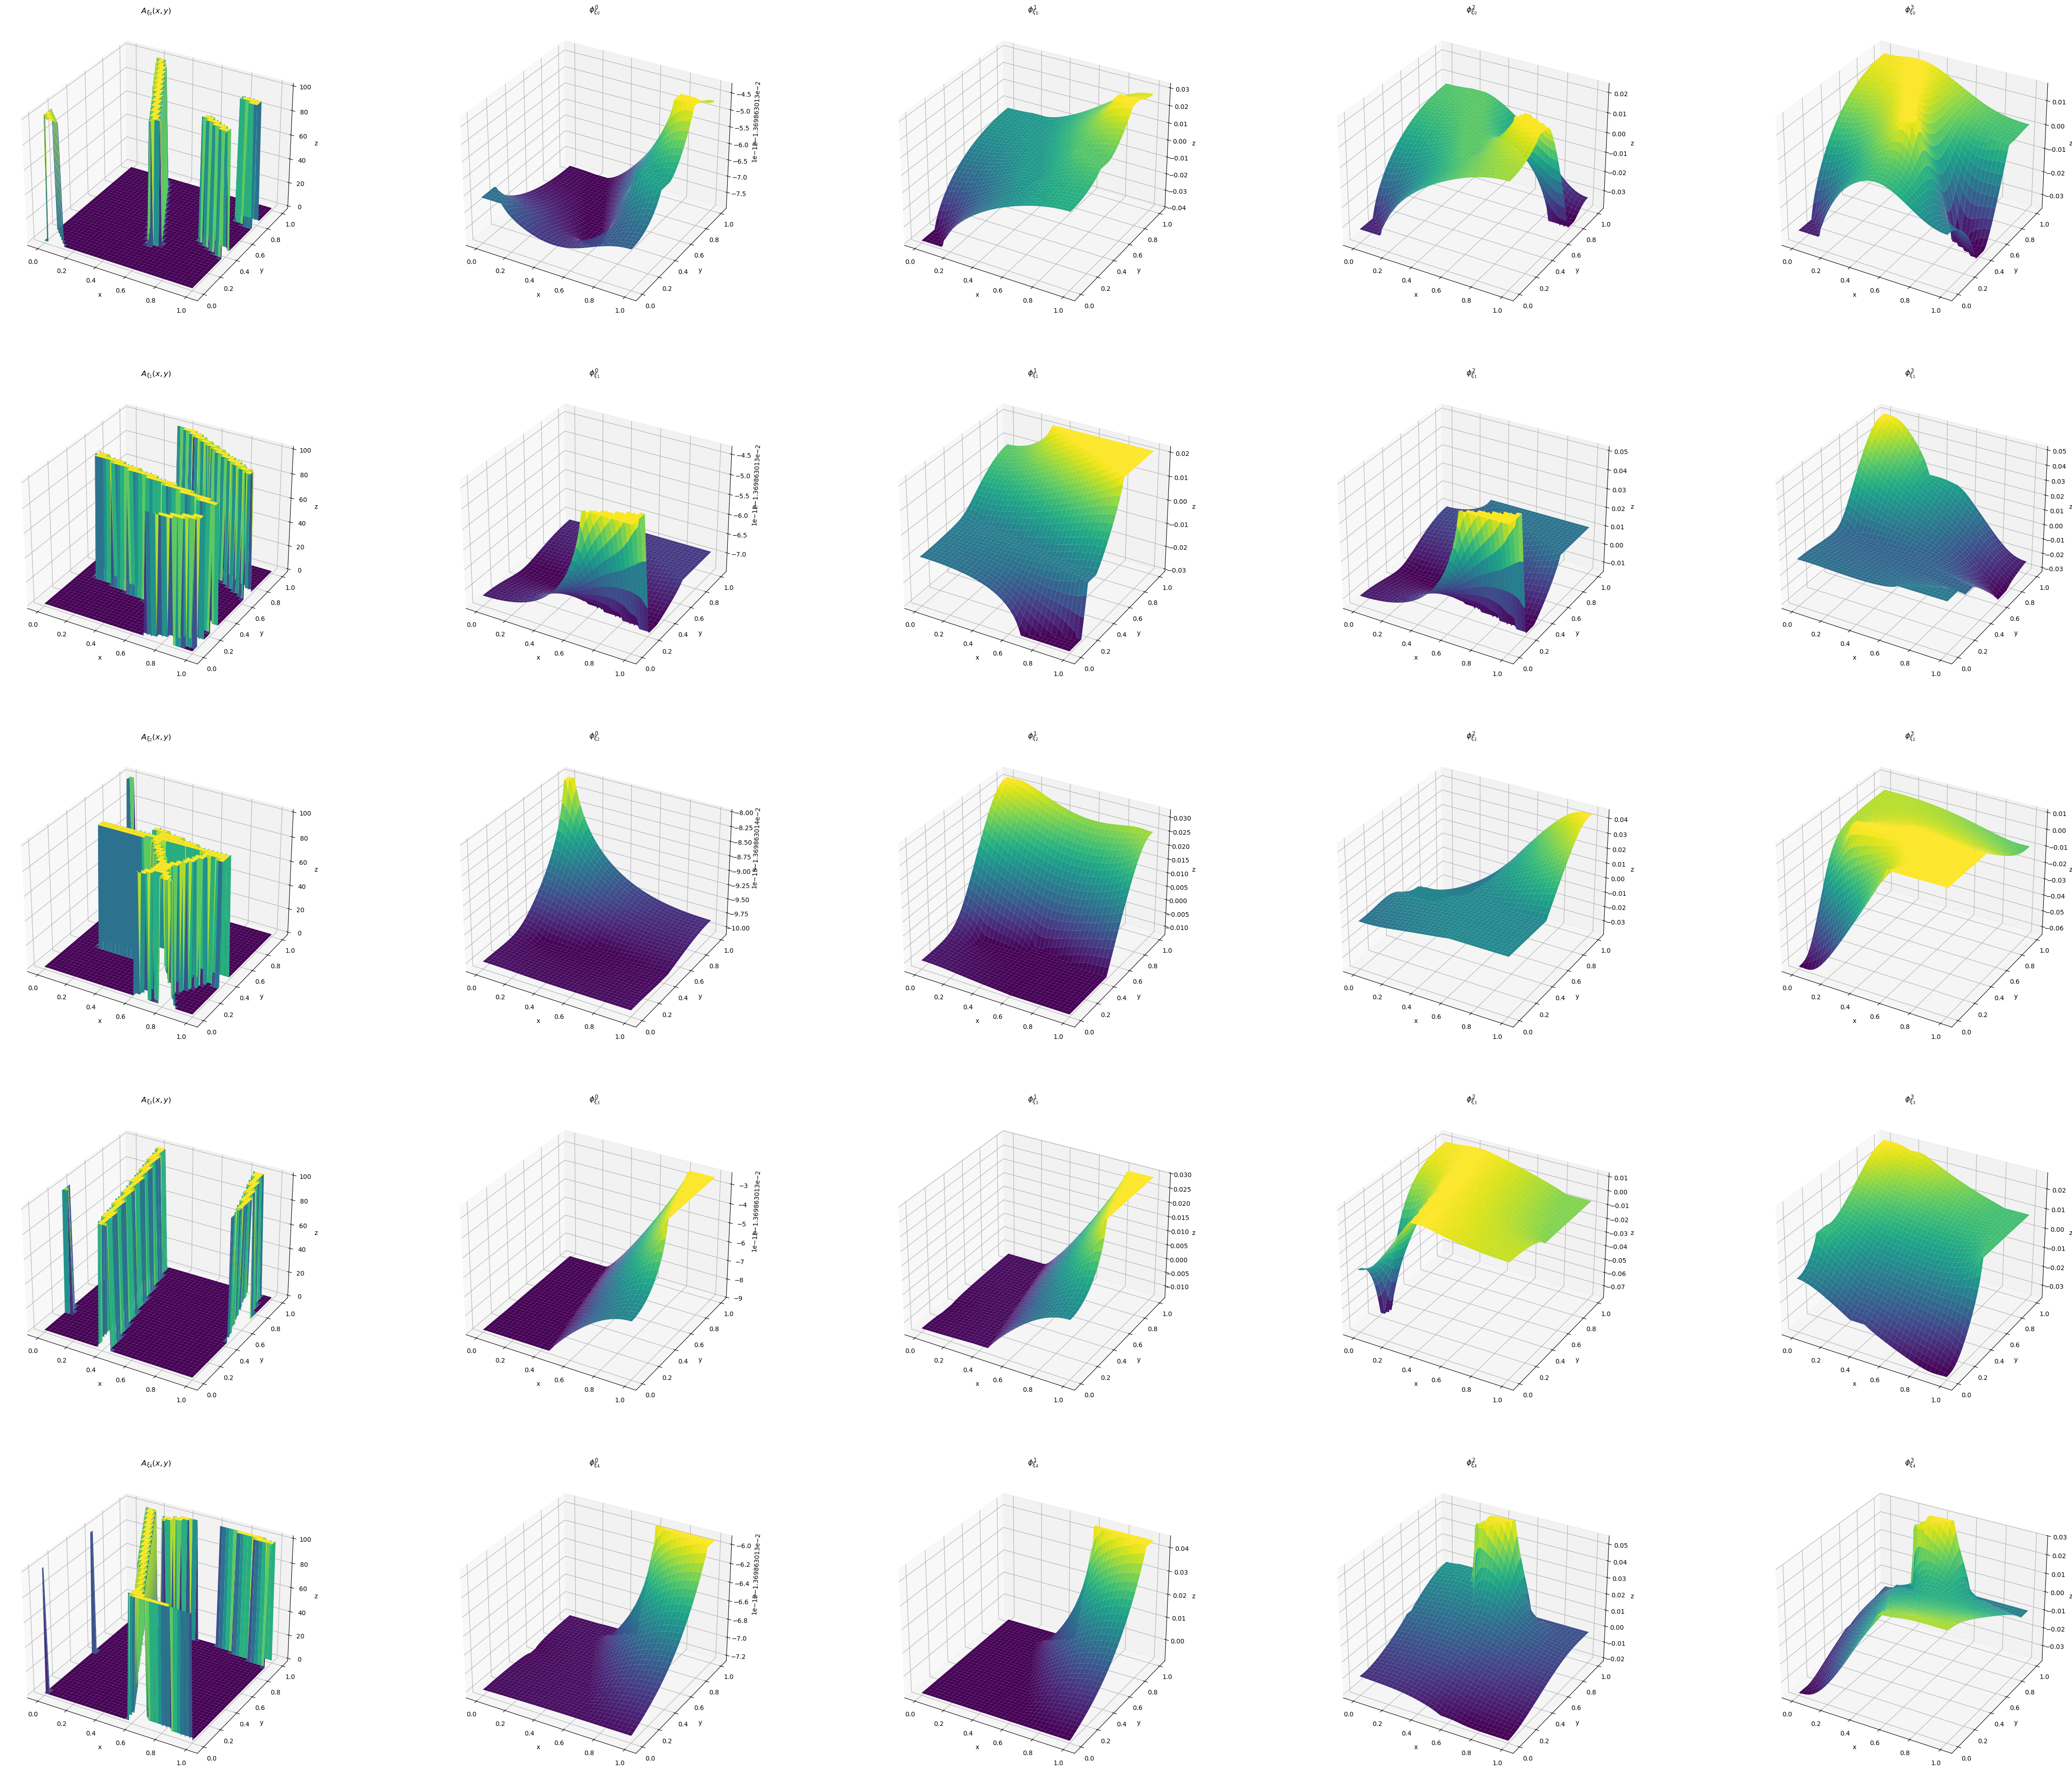

In [11]:
num_samples_case = 7
num_samples_to_plot = 5
store_tag = 'random_lines' # channel_smooth_coeff, sinus_coeff, channel_coeff
path_ = "data_FNO/%s/samples_%s"%(store_tag, num_samples_case)
if not ops.path.exists(path_):
    ops.makedirs(path_)
n_loc = 4
fig = plt.figure(figsize=(60, 10*num_samples_to_plot))

for s in range(num_samples_to_plot):
    coeff_A = np.load(ops.path.join(path_, "coeff_A_sub_dom_5_sample_%s.npy"%s))
    phi = np.load(ops.path.join(path_, "phi_sub_dom_5_sample_%s.npy"%s))
    for i in range(n_loc+1):
        ax = fig.add_subplot(num_samples_to_plot, n_loc + 1, s *(n_loc+1) + i + 1, projection='3d')
        if i == 0:
            # Keep the first column plot the same as before
            xs = np.linspace(0, 1, coeff_A.shape[0])
            X, Y = np.meshgrid(xs, xs)
            Z = coeff_A
            ax.set_title(r'$A_{\xi_%s}(x,y)$'%s)
            ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

        else:
            xs = np.linspace(0, 1, phi.shape[0])
            X, Y = np.meshgrid(xs, xs)
            Z = phi[:,:,i-1]
            ax.set_title(r'$\phi_{\xi_%s}^{%s}$'%(s,i-1))
            ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')

plot_dir = "plots/%s"%store_tag
if not ops.path.exists(plot_dir):
    ops.makedirs(plot_dir)
fig.savefig(ops.path.join(plot_dir,"coeff_A_and_basis_funcs_sub_dom_5.svg"))
plt.show()
